In [1]:
import pandas as pd

df = pd.read_csv(r"F:\AI-ML-BootCamp\NETSOL WORK\Week_5\athlete_events.csv")
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


In [3]:
df.columns

Index(['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games',
       'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'],
      dtype='object')

In [4]:
import pandas as pd

df = pd.read_csv("athlete_events.csv")
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Height'].fillna(df['Height'].median(), inplace=True)
df['Weight'].fillna(df['Weight'].median(), inplace=True)
df['Medal'].fillna('None', inplace=True)

C:\Users\Mani\AppData\Local\Temp\ipykernel_7180\983459541.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
C:\Users\Mani\AppData\Local\Temp\ipykernel_7180\983459541.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

In [5]:
#  Medal as binary for Bernoulli
df['Medal_binary'] = df['Medal'].apply(lambda x: 0 if x == 'None' else 1)

In [8]:
from scipy.stats import bernoulli

p = df['Medal_binary'].mean()  # probability of winning a medal
bernoulli_rv = bernoulli(p)
print(f"Probability of winning a medal: {p:.4f}")
print(f"Expected value (mean): {bernoulli_rv.mean():.4f}")
print(f"Variance: {bernoulli_rv.var():.4f}")

Probability of winning a medal: 0.1467
Expected value (mean): 0.1467
Variance: 0.1252


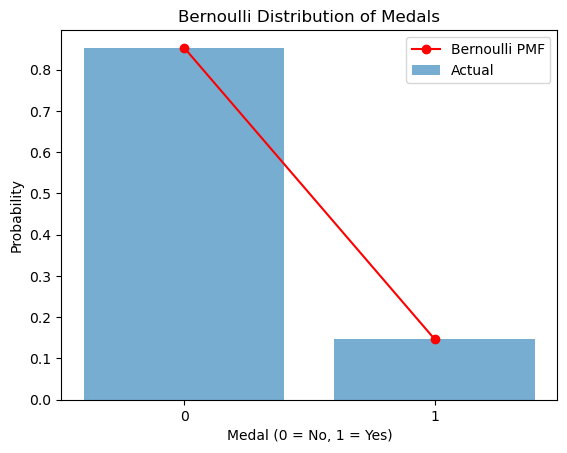

In [9]:
from scipy.stats import bernoulli
import matplotlib.pyplot as plt
import numpy as np

p = df['Medal_binary'].mean()
x = [0, 1]
plt.bar(x, [((df['Medal_binary']==0).sum()/len(df)), ((df['Medal_binary']==1).sum()/len(df))], alpha=0.6, label='Actual')
plt.plot(x, bernoulli.pmf(x, p), 'ro-', label='Bernoulli PMF')
plt.xticks(x)
plt.xlabel('Medal (0 = No, 1 = Yes)')
plt.ylabel('Probability')
plt.title('Bernoulli Distribution of Medals')
plt.legend()
plt.show()

In [12]:
# Binomial Distribution
from scipy.stats import binom

n = 10
x = np.arange(0, n+1)
binomial_probs = binom.pmf(x, n, p)
print(f"Binomial PMF values: {binomial_probs}")

Binomial PMF values: [2.04561743e-01 3.51790701e-01 2.72243055e-01 1.24849119e-01
 3.75736573e-02 7.75397963e-03 1.11122844e-03 1.09200654e-04
 7.04233124e-06 2.69131092e-07 4.62832464e-09]


In [13]:
sim_binom = binom.rvs(n, p, size=1000)

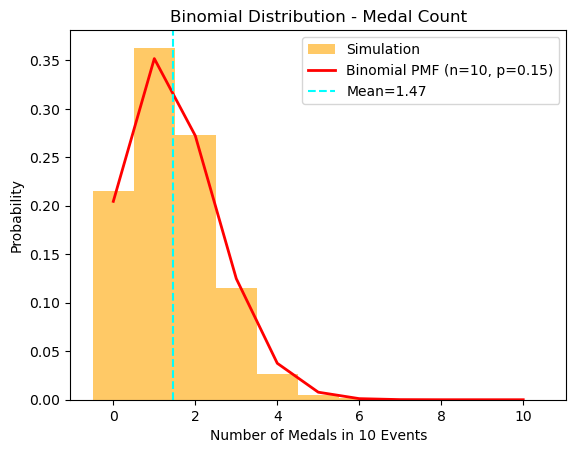

In [15]:
plt.hist(sim_binom, bins=np.arange(-0.5, n+1.5, 1), density=True, alpha=0.6, color='orange', label='Simulation')
plt.plot(x, binomial_probs, 'r-', lw=2, label=f'Binomial PMF (n={n}, p={p:.2f})')
plt.axvline(n*p, color='cyan', linestyle='dashed', label=f'Mean={n*p:.2f}')
plt.xlabel('Number of Medals in 10 Events')
plt.ylabel('Probability')
plt.title('Binomial Distribution - Medal Count')
plt.legend()
plt.show()

Normal Distribution

In [17]:
from scipy.stats import norm
height = df['Height'].dropna()
mu, sigma = height.mean(), height.std()
print(f"Mean={mu:.2f}, Std={sigma:.2f}")

Mean=175.26, Std=9.28


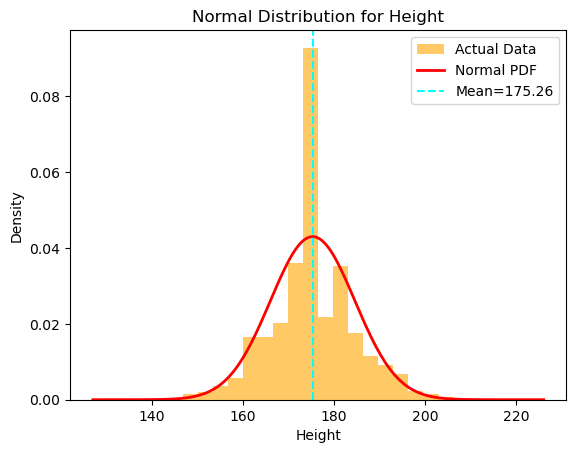

In [18]:
x = np.linspace(height.min(), height.max(), 200)
plt.hist(height, bins=30, density=True, alpha=0.6, color='orange', label='Actual Data')
plt.plot(x, norm.pdf(x, mu, sigma), 'r', lw=2, label='Normal PDF')
plt.axvline(mu, color='cyan', linestyle='dashed', label=f'Mean={mu:.2f}')
plt.xlabel('Height')
plt.ylabel('Density')
plt.title('Normal Distribution for Height')
plt.legend()
plt.show()

Poisson Distribution

In [20]:
from scipy.stats import poisson
medals_per_team = df.groupby('Team')['Medal_binary'].sum()
lambda_ = medals_per_team.mean()
print(f"medals per team : {lambda_:.2f}")

medals per team : 33.60


In [21]:
sim_poisson = poisson.rvs(lambda_, size=1000)

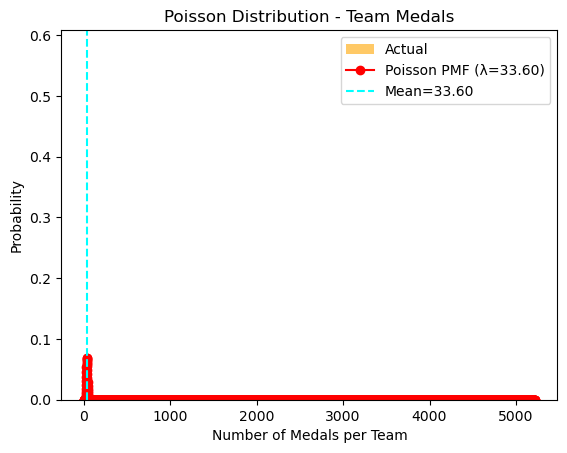

In [22]:
x = np.arange(0, medals_per_team.max()+1)
plt.hist(medals_per_team, bins=np.arange(0, medals_per_team.max()+2)-0.5, density=True, alpha=0.6, color='orange', label='Actual')
plt.plot(x, poisson.pmf(x, lambda_), 'ro-', label=f'Poisson PMF (λ={lambda_:.2f})')
plt.axvline(lambda_, color='cyan', linestyle='dashed', label=f'Mean={lambda_:.2f}')
plt.xlabel('Number of Medals per Team')
plt.ylabel('Probability')
plt.title('Poisson Distribution - Team Medals')
plt.legend()
plt.show()

Uniform Distribution

In [23]:
from scipy.stats import uniform
a, b = df['Age'].min(), df['Age'].max()
print(f"Uniform range: {a} to {b}")

Uniform range: 10.0 to 97.0


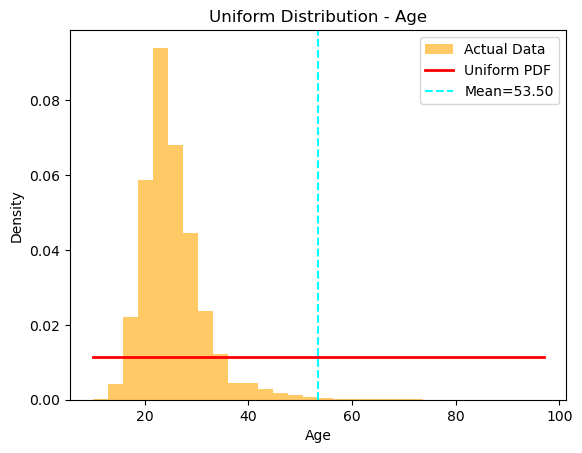

In [24]:
x = np.linspace(a, b, 200)
plt.hist(df['Age'], bins=30, density=True, alpha=0.6, color='orange', label='Actual Data')
plt.plot(x, uniform.pdf(x, a, b-a), 'r-', lw=2, label='Uniform PDF')
plt.axvline((a+b)/2, color='cyan', linestyle='dashed', label=f'Mean={(a+b)/2:.2f}')
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Uniform Distribution - Age')
plt.legend()
plt.show()

Exponential Distribution

In [25]:
from scipy.stats import expon

df['Year_diff'] = df.groupby('ID')['Year'].diff().fillna(0)
year_diff = df['Year_diff'][df['Year_diff']>0]
lambda_ = 1 / year_diff.mean()
print(f"Lambda for Exponential: {lambda_:.3f}")

Lambda for Exponential: 0.223


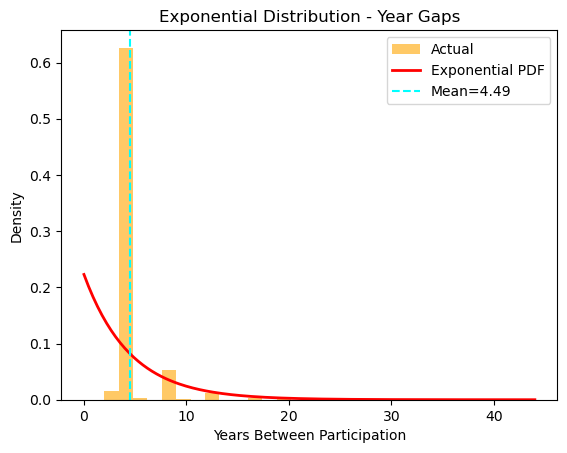

In [26]:
x = np.linspace(0, year_diff.max(), 200)
plt.hist(year_diff, bins=30, density=True, alpha=0.6, color='orange', label='Actual')
plt.plot(x, expon.pdf(x, scale=1/lambda_), 'r-', lw=2, label='Exponential PDF')
plt.axvline(1/lambda_, color='cyan', linestyle='dashed', label=f'Mean={1/lambda_:.2f}')
plt.xlabel('Years Between Participation')
plt.ylabel('Density')
plt.title('Exponential Distribution - Year Gaps')
plt.legend()
plt.show()

t-Distribution

In [27]:
from scipy.stats import t
weight = df['Weight'].dropna()
df_size = len(weight)

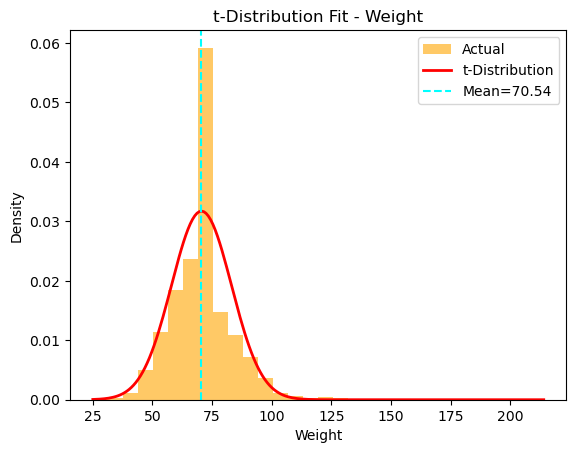

In [28]:
x = np.linspace(weight.min(), weight.max(), 200)
plt.hist(weight, bins=30, density=True, alpha=0.6, color='orange', label='Actual')
plt.plot(x, t.pdf(x, df_size-1, loc=weight.mean(), scale=weight.std()), 'r-', lw=2, label=f't-Distribution')
plt.axvline(weight.mean(), color='cyan', linestyle='dashed', label=f'Mean={weight.mean():.2f}')
plt.xlabel('Weight')
plt.ylabel('Density')
plt.title('t-Distribution Fit - Weight')
plt.legend()
plt.show()